### Online retail store analytics

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv(
    r"C:\Users\heisBabalola\Desktop\Datasets\OnlineRetail.csv", encoding="latin-1"
)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [4]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

#### Checking for nulls in CustomerID

In [5]:
df["CustomerID"].isnull().sum()

np.int64(135080)

#### Check for missing dates

In [6]:
df["InvoiceDate"].isnull().sum()

np.int64(0)

#### Check for negative quantities

In [7]:
df["Quantity"].astype(str).str.startswith("-").sum()

np.int64(10624)

#### Final cleaning and filtering

In [8]:
df = df[df["Country"] != "United Kingdom"]
df = df[~df["InvoiceNo"].astype(str).str.startswith("C")]
df["TotalSales"] = df["Quantity"] * df["UnitPrice"]
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalSales
26,536370,22728,ALARM CLOCK BAKELIKE PINK,24,2010-12-01 08:45:00,3.75,12583.0,France,90.00
27,536370,22727,ALARM CLOCK BAKELIKE RED,24,2010-12-01 08:45:00,3.75,12583.0,France,90.00
28,536370,22726,ALARM CLOCK BAKELIKE GREEN,12,2010-12-01 08:45:00,3.75,12583.0,France,45.00
29,536370,21724,PANDA AND BUNNIES STICKER SHEET,12,2010-12-01 08:45:00,0.85,12583.0,France,10.20
30,536370,21883,STARS GIFT TAPE,24,2010-12-01 08:45:00,0.65,12583.0,France,15.60
...,...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France,10.20
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France,12.60
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60


#### Making sure the new dataset meets the requirement

In [9]:
df.shape

(44999, 9)

#### Adding new columns

In [10]:
df["Saleshour"] = df["InvoiceDate"].dt.hour
df["Salesday"] = df["InvoiceDate"].dt.day_name()
df["Salesmonth"] = df["InvoiceDate"].dt.month_name()

In [11]:
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalSales,Saleshour,Salesday,Salesmonth
26,536370,22728,ALARM CLOCK BAKELIKE PINK,24,2010-12-01 08:45:00,3.75,12583.0,France,90.00,8,Wednesday,December
27,536370,22727,ALARM CLOCK BAKELIKE RED,24,2010-12-01 08:45:00,3.75,12583.0,France,90.00,8,Wednesday,December
28,536370,22726,ALARM CLOCK BAKELIKE GREEN,12,2010-12-01 08:45:00,3.75,12583.0,France,45.00,8,Wednesday,December
29,536370,21724,PANDA AND BUNNIES STICKER SHEET,12,2010-12-01 08:45:00,0.85,12583.0,France,10.20,8,Wednesday,December
30,536370,21883,STARS GIFT TAPE,24,2010-12-01 08:45:00,0.65,12583.0,France,15.60,8,Wednesday,December
...,...,...,...,...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France,10.20,12,Friday,December
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France,12.60,12,Friday,December
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60,12,Friday,December
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60,12,Friday,December


#### Average order value per transaction

In [12]:
aov = df.groupby("InvoiceNo")[["TotalSales"]].sum().mean()
print(f"Average order value per transaction is {aov['TotalSales'].round(2)}")

Average order value per transaction is 845.24


#### Total number of customers

In [13]:
print(f"Total number of customers is {df['CustomerID'].nunique()}")

Total number of customers is 418


#### Top 10 best selling products

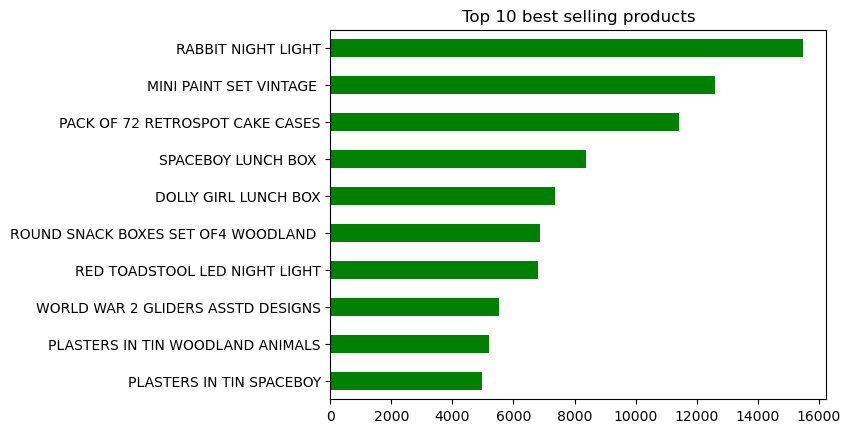

In [14]:
df.groupby("Description")[["Quantity"]].sum().sort_values(
    by=["Quantity"], ascending=True
).tail(10).plot(kind="barh", color="green", legend=False)
plt.title("Top 10 best selling products")
plt.ylabel("")
plt.show()

#### Top 10 revenue products

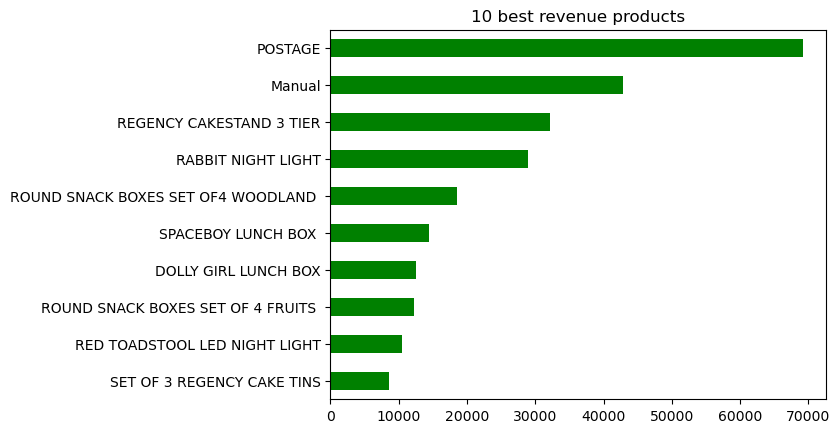

In [15]:
df.groupby("Description")[["TotalSales"]].sum().sort_values(
    by=["TotalSales"], ascending=True
).tail(10).plot(kind="barh", color="green", legend=False)
plt.title("10 best revenue products")
plt.ylabel("")
plt.show()

#### Sales by hour

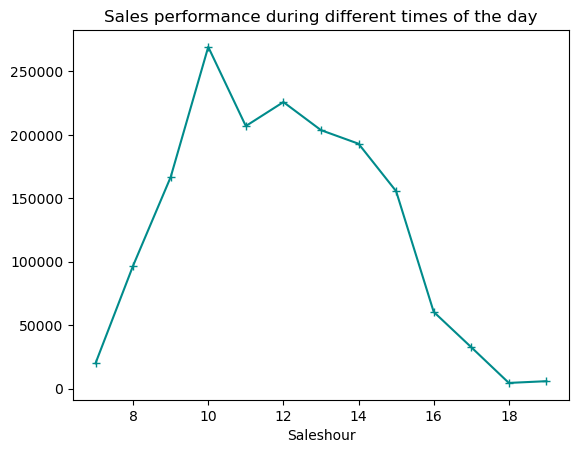

In [16]:
df.groupby("Saleshour")[["TotalSales"]].sum().plot(
    kind="line", color="darkcyan", marker="+", legend=False
)
plt.title("Sales performance during different times of the day")
plt.show()

#### Sales by day

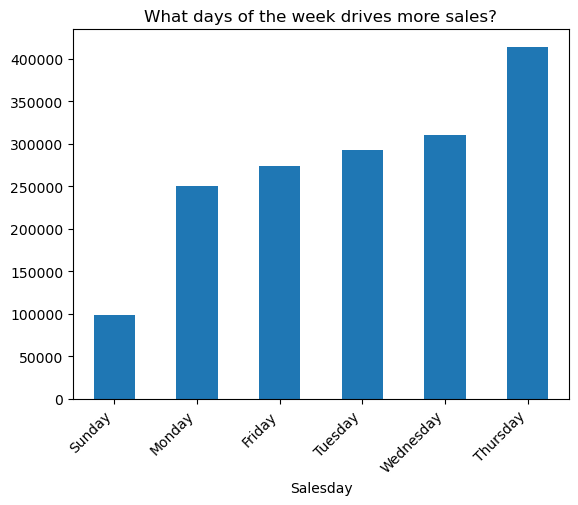

In [17]:
df.groupby("Salesday")[["TotalSales"]].sum().sort_values(
    by=["TotalSales"], ascending=True
).plot(kind="bar", legend=False)
plt.title("What days of the week drives more sales?")
plt.xticks(rotation=45, ha="right")
plt.show()

#### Top 10 customers by revenue

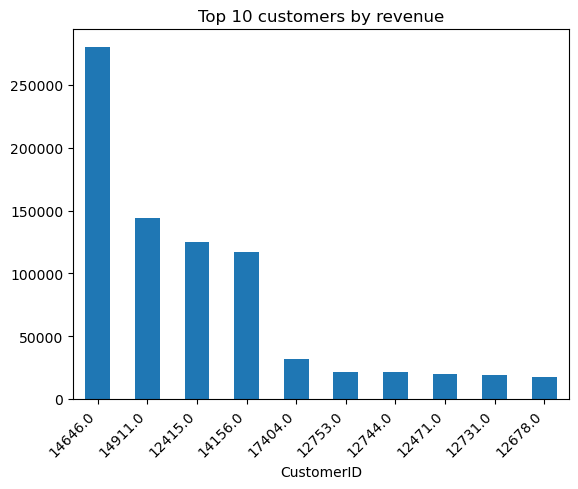

In [18]:
df.groupby("CustomerID")[["TotalSales"]].sum().sort_values(
    by="TotalSales", ascending=False
).head(10).plot(kind="bar", legend=False)
plt.xticks(rotation=45, ha="right")
plt.title("Top 10 customers by revenue")
plt.show()

##### Who are the repeat customers?

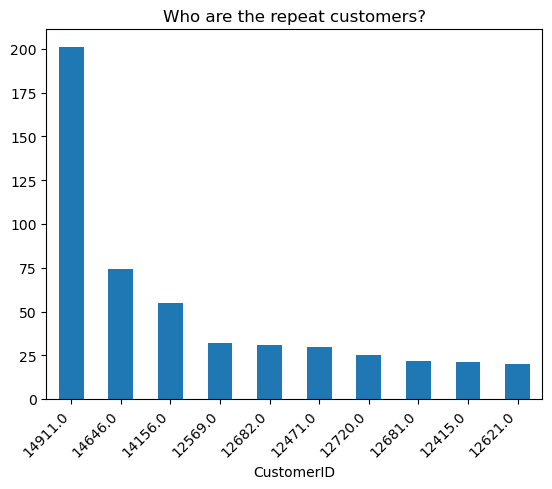

In [19]:
df.groupby("CustomerID")[["InvoiceNo"]].nunique().sort_values(
    by="InvoiceNo", ascending=False
).head(10).plot(kind="bar", legend=False)
plt.title("Who are the repeat customers?")
plt.xticks(rotation=45, ha="right")
plt.show()

#### Which month generates the most revenue?

In [20]:
seasonality = df.pivot_table(
    index="Salesmonth", values="TotalSales", aggfunc="sum"
).reset_index()

seasonality["month_no"] = pd.to_datetime(
    seasonality["Salesmonth"], format="%B"
).dt.month

seasonality = seasonality.sort_values(by="month_no").reset_index(drop=True)

seasonality = seasonality.drop(columns="month_no")

seasonality.set_index("Salesmonth", inplace=True)

<Axes: title={'center': 'Which months generate the most revenue?'}, xlabel='Salesmonth'>

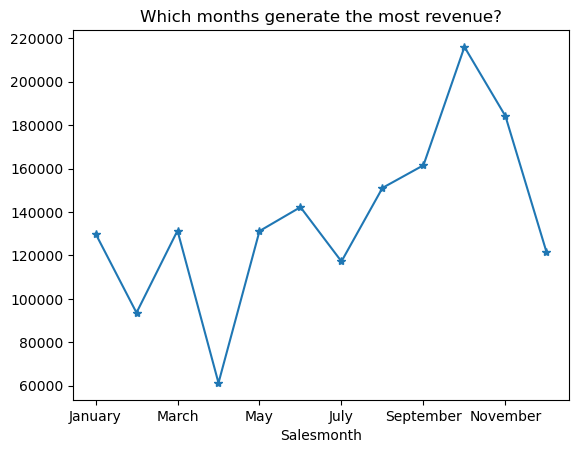

In [21]:
seasonality.plot(
    kind="line",
    legend=False,
    title="Which months generate the most revenue?",
    marker="*",
)

##### Saving the cleaned CSV

In [22]:
# Saving to a specific path
# df.to_csv(r"C:\Users\heisBabalola\Desktop\Datasets\online_sales_data_cleaned.csv", index=False)